<a href="https://colab.research.google.com/github/heisenberg304/Housing-Prices-prediction/blob/develop/analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%writefile data_housing.py

import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/data_csv/Housing.csv")


Writing data_housing.py


In [ ]:
from data_housing import data

#revisar si hay valores faltantes con:
data.isnull().sum().sort_values()
#despues de usar esto, revise detenidamente y no encontre valores faltantes

#revisar informacion
data.info()
#veo cuales son objetos y cuales son valores numericos

#analizar deesviacion estandar, media y mediana
data.describe()
#identificar que features tienen extremos tanto arriba como abajo

#analizar como se dividen los valores categoricos nominales binarios
#mainroad
#guestroom
#basement
#hotwaterheating
#airconditioning
#prefarea
#furnishingstatus
data["mainroad"].value_counts() #probe a cada categotico


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,count
mainroad,
yes,468
no,77


#Analizando mean y median de features

-Valores Extremos superiores:
Price,
Area

LLegue a esta conclusion dado que en estos features mean > median

---
-Valores Extremos inferiores:
Stories (numerico discreto)

LLegue a esta conclusion dado que en estos features median > mean

---
-No hay valores extremos notables:
Bedrooms,
Bathrooms
LLegue a esta conclusion ya que mean es bastante igual a median

#Clasificacion de features
##Numericos:
price

area

bedrooms (discreto)

bathrooms (discreto)

stories (discreto)

parking (discreto)

##Categoricos:
furnishingstatus: semi-furnished = 227;
unfurnished = 178;
furnished = 140


###Categórica nominal binaria:
mainroad: yes = 468; no = 77

guestroom: yes = 97; no = 448

basement: yes = 191; no = 354

hotwaterheating: yes = 25; no = 520

airconditioning: yes = 172; no = 373

prefarea: yes = 128; no = 417



In [ ]:
from data_housing import data
import matplotlib.pyplot as plt
import numpy as np

price = data["price"]
plt.hist(np.log1p(price)) #np.expm1(price) para descomprimir
plt.ylabel("cantidad de casas")
plt.xlabel("Precio log")
plt.show()

area = data["area"]
plt.hist(np.log1p(area))
plt.ylabel("cantidad de casas")
plt.xlabel("Area log")
plt.show()

#numericas discretas:

plt.hist(data["bedrooms"])
plt.ylabel("cantidad de casas")
plt.xlabel("Bedrooms")
plt.show()

plt.hist(data["bathrooms"])
plt.ylabel("cantidad de casas")
plt.xlabel("Bathrooms")
plt.show()

plt.hist(data["stories"])
plt.ylabel("cantidad de casas")
plt.xlabel("Stories")
plt.show()

plt.hist(data["parking"])
plt.ylabel("cantidad de casas")
plt.xlabel("Parking")
plt.show()

#DISTRIBUCIONES DE FEATURES NUMERICOS:

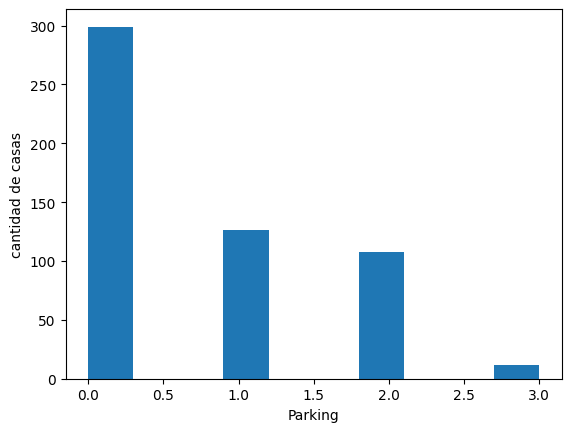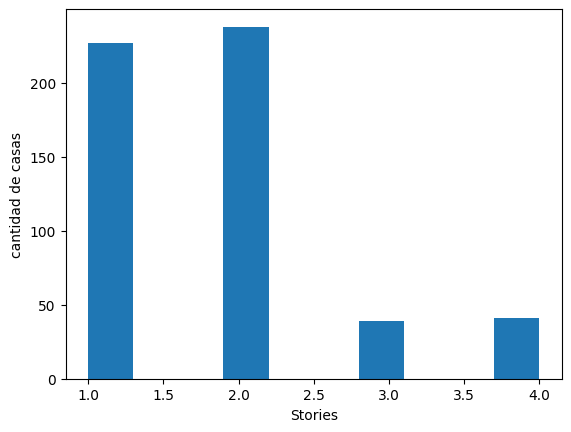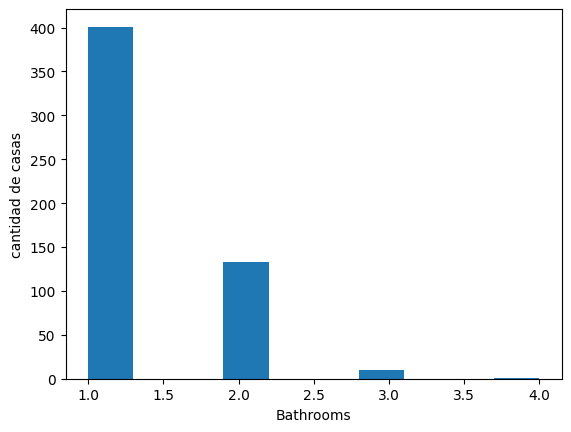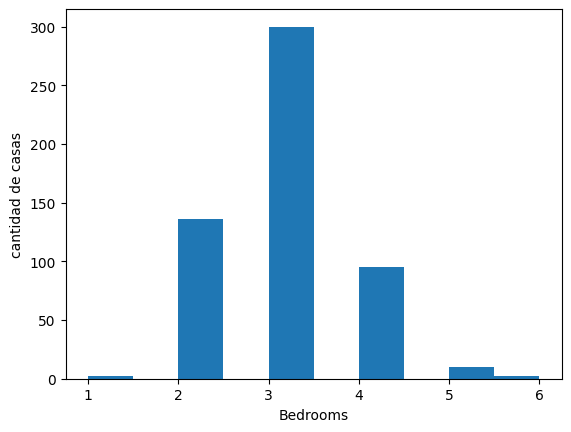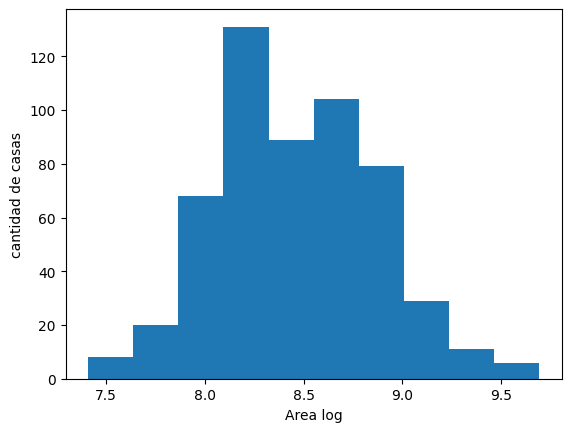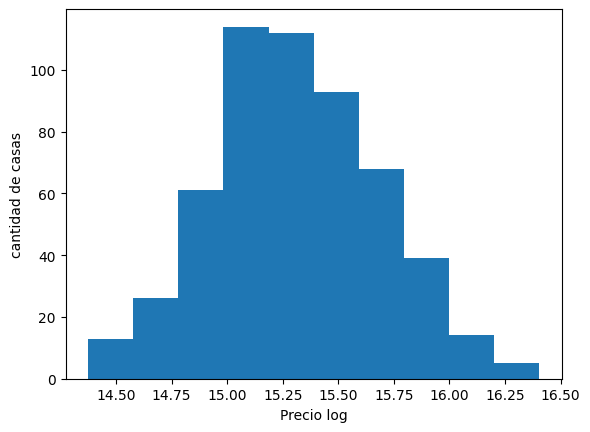

#Analisis de la distribucion de las variables categoricas

##Price:
En price usamos log1p para tener una distribucion mas compacta, mas equilibrada,

##Area:


##Bedrooms:


##Bathrooms:


##Stories:


##Parking:



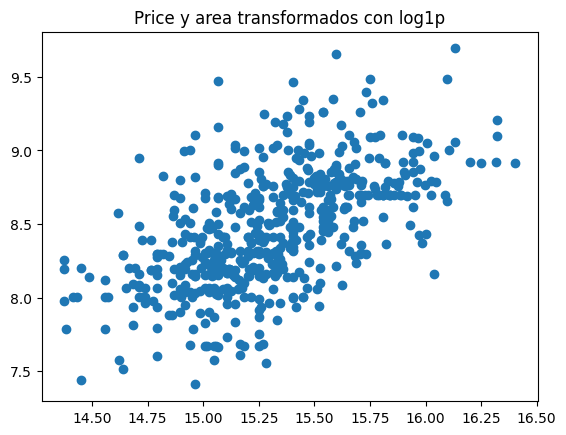

In [11]:
from data_housing import data
import matplotlib.pyplot as plt
import numpy as np

price = np.log1p(data["price"])
area = np.log1p(data["area"])
plt.scatter(price, area)
plt.title("Price y area transformados con log1p")
plt.show()

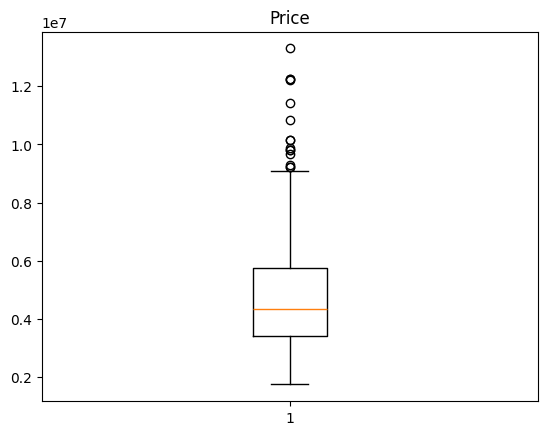

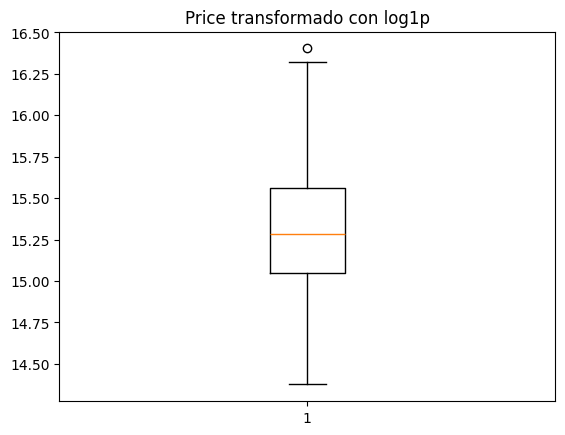

In [10]:
from data_housing import data
import matplotlib.pyplot as plt
import numpy as np

price = data["price"]
plt.boxplot(price)
plt.title("Price")
plt.show()

plt.boxplot(np.log1p(price))
plt.title("Price transformado con log1p")
plt.show()

si

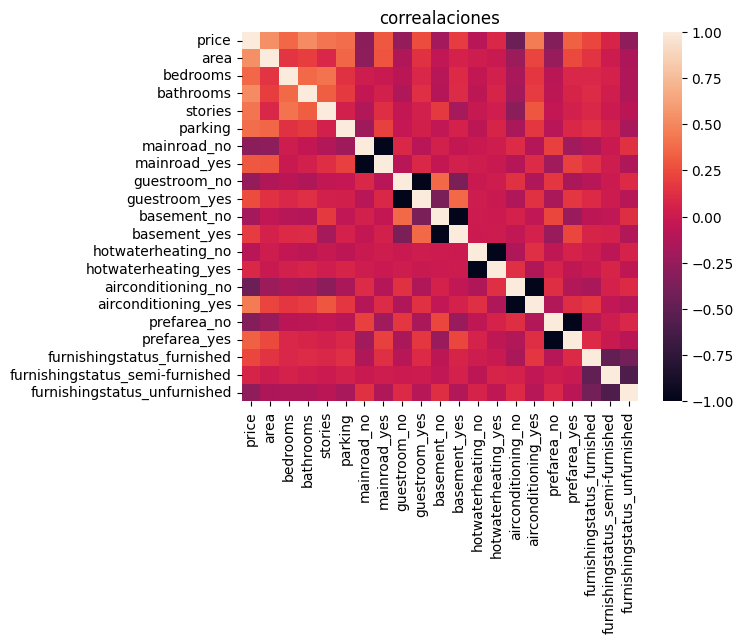

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning_yes,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea_yes,0.329777
mainroad_yes,0.296898
guestroom_yes,0.255517


In [24]:
from data_housing import data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



data = pd.get_dummies(data, columns=["mainroad"])
data = pd.get_dummies(data, columns=["guestroom"])
data = pd.get_dummies(data, columns=["basement"])
data = pd.get_dummies(data, columns=["hotwaterheating"])
data = pd.get_dummies(data, columns=["airconditioning"])
data = pd.get_dummies(data, columns=["prefarea"])
data = pd.get_dummies(data, columns=["furnishingstatus"])

corr = data.corr()
sns.heatmap(corr)
plt.title("correalaciones")
plt.show()


target_corr = (data.corr(numeric_only=True)['price'].sort_values(ascending=False))
display(target_corr)

si